##Encoding Algorithm for Jpeg
1. RGB to Ycbcr conversion
2.convert to 8*8 macroblock
3.DCT transformation
4.Quantization to reduce effect of high frequency component (lossy compression)
5.Further compressed with losseless algorithm (Run length Encoding which uses zig zag scanning)

In [ ]:
import cv2
import numpy as np

def BGR_to_YCbCr(img):
'''
  converting the image from the RGB color space to YCbCr. 
  This conversion separates brightness information (Y) from chrominance information (Cb and Cr), 
  as the human eye is more sensitive to brightness than color differences.
  Y = 0.299 * R + 0.587 * G + 0.114 * B
 Cb = 128 - (0.168736 * R) - (0.331264 * G) + 0.5 * B
 Cr = 128 + 0.5 * R - (0.418688 * G) - (0.081312 * B)

'''
  h = img.shape[0]
  w = img.shape[1]
  ycbcr = np.zeros((h,w,3))
  for i in range (h):
    for j in range (w):
      r = img[i,j,2]
      g = img[i,j,1]
      b = img[i,j,0]
      y = (0.299*r) + (0.587*g) + (0.114*b)
      cb = 128 - (0.168736*r) - (0.331264*g) + (0.5*b)
      cr = 128 + (0.5*r) - (0.418688*g) - (0.081312*b)
      ycbcr[i,j,0] = y
      ycbcr[i,j,1] = cb
      ycbcr[i,j,2] = cr
  return ycbcr

def macroblock(img,channel):
  '''
  Each channel must be split into 8×8 blocks. Fill the remaining area of the incomplete blocks with
  Filling the edges with a fixed color (for example, black)

  '''
  H = img.shape[0]
  W = img.shape[1]

  while(H%8!=0):
    H+=1
  while(W%8!=0):
    W+=1
  n = (H//8)*(W//8)

  img1 = np.zeros((H,W,3))
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      img1[i,j,:] = img[i,j,:]

  img_res = np.zeros((n,8,8))
  k = 0
  for i in range(H//8):
    for j in range(W//8):
      img_res[k,:,:] = img1[i*8:(i*8)+8,j*8:(j*8)+8,channel]
      k += 1
  return img_res

def dct_1d(x):
  '''
  apply the Discrete Cosine Transform (DCT) to each 8x8 block of the Y, Cb, and Cr 
  DCT transforms the spatial image data into frequency components, 
  concentrating energy in the low-frequency coefficients, which helps in the compression
  1D gives for particular row or colum
  '''
  N=x.shape[0]
  dct=np.zeros(N)
  for k in range(N):
    dct[k]=0
    for n in range(N):
      dct[k]+=x[n]*np.cos((2*n+1)*k*np.pi/(2*N))
    if k==0:
      dct[k]/=np.sqrt(N)
    else:
      dct[k]*=np.sqrt(2/N)
  return dct

def dct_2d(img):
  h,w=img.shape
  img_dct_row=np.zeros((h,w))
  img_dct_col=np.zeros((h,w))
  for i in range(h):
    img_dct_row[i,:]=dct_1d(img[i,:])

  for j in range(w):
    img_dct_col[:,j]=dct_1d(img_dct_row[:,j])
  return img_dct_col

def zig_zag_scanning(x):
  '''
  applies zig-zag scanning to the 8x8 DCT coefficients to convert the 2D array into a 1D array. 
  This ordering groups low-frequency coefficients at the beginning
 where more data is concentrated, and high-frequency coefficients at the end
'''
  n = x.shape[0]
  N = (n-1)*2
  index = 0
  y = np.zeros((1,n**2),dtype="int")
  for sum in range(N+1):
    if(sum<=n-1):
      freq = sum+1
      i = sum
      j = 0
      while(freq>0 and i<n and j>=0):
        if(sum%2==0):
          y[0,index] = x[i,j]
        else:
          y[0,index] = x[j,i]
        index+=1
        freq-=1
        i-=1
        j+=1
    else:
      i = n-1
      j = sum-n+1
      freq = N-sum+1
      while(freq>0 and i>=sum-n+1 and j<n):
        if(sum%2==0):
          y[0,index] = x[i,j]
        else:
          y[0,index] = x[j,i]
        index+=1
        freq-=1
        i-=1
        j+=1
  return y

def run_length_encoding(x):
  '''
  Run-Length Encoding (RLE) to encode these runs of zeros efficiently by replacing them with a single (Run-Length, Value) pair
  '''
  n = x.shape[0]
  l = x.shape[1]
  r = 0
  rle_mat=np.zeros((1,3),dtype="int")
  for k in range(n):
    for index in range(l):
      if(x[k,index]==0):
        r += 1
        if(r==15):
          rlc_ele = np.array([r,0,0],dtype="int")
          rle_mat=np.concatenate((rle_mat,rlc_ele.reshape(1,3)),axis=0)
          r = 0
          break
      else:
        s = int(np.ceil(np.log2(1 + np.abs(x[k,index]))))
        rlc_ele=np.array([r,s,x[k,index]],dtype="int")
        rle_mat=np.concatenate((rle_mat,rlc_ele.reshape(1,3)),axis=0)
        r = 0
  rle_mat=np.delete(rle_mat,0,0)
  return (rle_mat)

quantization_Y = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
     [12, 12, 14, 19, 26, 58, 60, 55],
     [14, 13, 16, 24, 40, 57, 69, 56],
     [14, 17, 22, 29, 51, 87, 80, 62],
     [18, 22, 37, 56, 68, 109, 103, 77],
     [24, 35, 55, 64, 81, 104, 113, 92],
     [49, 64, 78, 87, 103, 121, 120, 101],
     [72, 92, 95, 98, 112, 100, 103, 99]
 ])
quantization_C = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 66, 99, 99, 99, 99, 99],
    [47, 66, 99 ,99 ,99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
 ])

##Encoding

In [ ]:
def compression(image):
  ycbcr = BGR_to_YCbCr(image)
  Y = macroblock(ycbcr,0)
  Cb = macroblock(ycbcr,1)
  Cr = macroblock(ycbcr,2)
  n = Y.shape[0]
  enc_Y = np.zeros((n,64),dtype="int")
  enc_Cb = np.zeros((n,64),dtype="int")
  enc_Cr = np.zeros((n,64),dtype="int")
  for k in range(n):
    Y[k,:,:] = Y[k,:,:] - 128
    Cb[k,:,:] = Cb[k,:,:] - 128
    Cr[k,:,:] = Cr[k,:,:] - 128
    Y[k,:,:] = dct_2d(Y[k,:,:])
    Cb[k,:,:] = dct_2d(Cb[k,:,:])
    Cr[k,:,:] = dct_2d(Cr[k,:,:])
    for i in range(8):
      for j in range(8):
        Y[k,i,j] = round(Y[k,i,j]/quantization_Y[i,j])
        Cb[k,i,j] = round(Cb[k,i,j]/quantization_C[i,j])
        Cr[k,i,j] = round(Cr[k,i,j]/quantization_C[i,j])
    enc_Y[k,:] = zig_zag_scanning(Y[k,:,:])
    enc_Cb[k,:] = zig_zag_scanning(Cb[k,:,:])
    enc_Cr[k,:] = zig_zag_scanning(Cr[k,:,:])
  print("First Luminance Block after Quantization:")
  print(Y[0,:,:])
  print("First Luminance Block after Zig-Zag Scanning:")
  print(enc_Y[0,:])
  print("First Cb Block after Quantization:")
  print(Cb[0,:,:])
  print("First Cb Block after Zig-Zag Scanning:")
  print(enc_Cb[0,:])
  print("First Cr Block after Quantization:")
  print(Cr[0,:,:])
  print("First Cr Block after Zig-Zag Scanning:")
  print(enc_Cr[0,:])
  print("Last Luminance Block after Quantization:")
  print(Y[n-1,:,:])
  print("Last Luminance Block after Zig-Zag Scanning:")
  print(enc_Y[n-1,:])
  print("Last Cb Block after Quantization:")
  print(Cb[n-1,:,:])
  print("Last Cb Block after Zig-Zag Scanning:")
  print(enc_Cb[n-1,:])
  print("Last Cr Block after Quantization:")
  print(Cr[n-1,:,:])
  print("Last Cr Block after Zig-Zag Scanning:")
  print(enc_Cr[n-1,:])

  return enc_Y,enc_Cb,enc_Cr

# img = cv2.imread("corn.bmp")
# img = cv2.imread("pepper.bmp")
img = cv2.imread("cameraman.bmp")
e_Y,e_Cb,e_Cr = compression(img)
rle_Y = run_length_encoding(e_Y)
rle_Cb = run_length_encoding(e_Cb)
rle_Cr = run_length_encoding(e_Cr)

print("Luminance Block after Run-Length Encoding:")
print(rle_Y)
print("Cb Block after Run-Length Encoding:")
print(rle_Cb)
print("Cr Block after Run-Length Encoding:")
print(rle_Cr)

First Luminance Block after Quantization:
[[22.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]
First Luminance Block after Zig-Zag Scanning:
[22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
First Cb Block after Quantization:
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
First Cb Block after Zig-Zag Scanning:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
First Cr Bloc

##Compression ratio after encoding

In [ ]:

def max_bits(x):
  r = x[:,0].max()
  s = x[:,1].max()
  a = x[:,2].max()
  if(a==0):
    return 0
  else:
    rb = int(np.ceil(np.log2(1 + np.abs(r))))
    sb = int(np.ceil(np.log2(1 + np.abs(s))))
    ab = int(np.ceil(np.log2(1 + np.abs(a))))
    xb = (rb + sb + ab)*(x.shape[0])
    return xb

H,W,p = img.shape
bits_total = H*W*p*8
print("bits required for original image to transmit ",bits_total ,sep=' ---> ' )
yb = max_bits(rle_Y)
cb = max_bits(rle_Cb)
cr = max_bits(rle_Cr)
bits_compressed = yb + cb + cr
print("bits required after encoding",bits_compressed,sep=' ---> ')
compression_ratio = bits_total/bits_compressed
print( "Compression ratio",compression_ratio,sep=' ---> ')

bits required for original image to transmit  ---> 1215000
bits required after encoding ---> 139687
Compression ratio ---> 8.698017711025363


##Decoding Functions
Mainly contains reverse of encoding

In [ ]:

import numpy as np
def inverse_zig_zag_scanning(x, n):
    y = np.zeros((n, n), dtype="int")
    index = 0
    for sum in range(2 * n - 1):
        if (sum <= n - 1):
            freq = sum + 1
            i = sum
            j = 0
            while (freq > 0 and i >= 0 and j < n):
                if (sum % 2 == 0):
                    y[i, j] = x[index]
                else:
                    y[j, i] = x[index]
                index += 1
                freq -= 1
                i -= 1
                j += 1
        else:
            i = n - 1
            j = sum - n + 1
            freq = 2 * n - sum - 1
            while (freq > 0 and i >= sum - n + 1 and j < n):
                if (sum % 2 == 0):
                    y[i, j] = x[index]
                else:
                    y[j, i] = x[index]
                index += 1
                freq -= 1
                i -= 1
                j += 1
    return y

def inverse_dct_1d(x):
    N = x.shape[0]
    idct = np.zeros(N)
    for n in range(N):
        idct[n] = 0
        for k in range(N):
            if k == 0:
                idct[n] += x[k] / np.sqrt(N) * np.cos((2 * n + 1) * k * np.pi / (2 * N))
            else:
                idct[n] += np.sqrt(2 / N) * x[k] * np.cos((2 * n + 1) * k * np.pi / (2 * N))
    return idct

def inverse_dct_2d(img):
    h, w = img.shape
    img_idct_col = np.zeros((h, w))
    img_idct_row = np.zeros((h, w))

    for j in range(w):
        img_idct_col[:, j] = inverse_dct_1d(img[:, j])
    for i in range(h):
        img_idct_row[i, :] = inverse_dct_1d(img_idct_col[i, :])
    return img_idct_row

def decompression(e_Y, e_Cb, e_Cr, quantization_Y, quantization_C):
    n = e_Y.shape[0]
    Y = np.zeros((n, 8, 8))
    Cb = np.zeros((n, 8, 8))
    Cr = np.zeros((n, 8, 8))
    for k in range(n):
        Y[k, :, :] = inverse_zig_zag_scanning(e_Y[k, :], 8)
        Cb[k, :, :] = inverse_zig_zag_scanning(e_Cb[k, :], 8)
        Cr[k, :, :] = inverse_zig_zag_scanning(e_Cr[k, :], 8)
        for i in range(8):
            for j in range(8):
                Y[k, i, j] = Y[k, i, j] * quantization_Y[i, j]
                Cb[k, i, j] = Cb[k, i, j] * quantization_C[i, j]
                Cr[k, i, j] = Cr[k, i, j] * quantization_C[i, j]
        Y[k, :, :] = inverse_dct_2d(Y[k, :, :])
        Cb[k, :, :] = inverse_dct_2d(Cb[k, :, :])
        Cr[k, :, :] = inverse_dct_2d(Cr[k, :, :])
        Y[k,:,:] = Y[k,:,:] + 128
        Cb[k,:,:] = Cb[k,:,:] + 128
        Cr[k,:,:] = Cr[k,:,:] + 128
    return Y, Cb, Cr


##Image Reconstruction

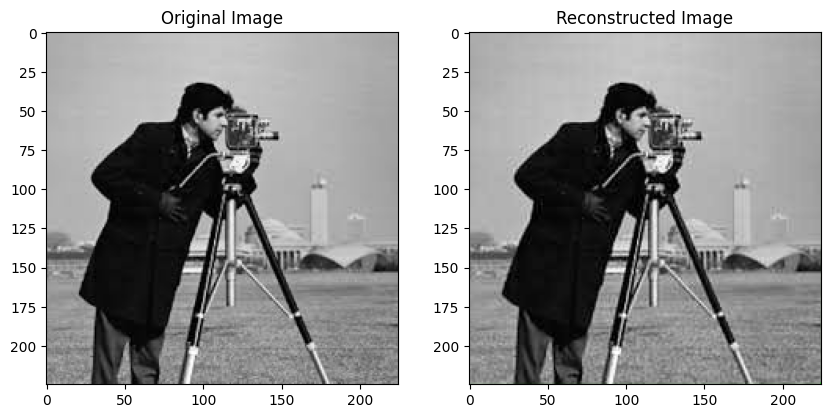

In [ ]:


import cv2
import numpy as np
import matplotlib.pyplot as plt

# ... (Your existing code for BGR_to_YCbCr, macroblock, dct_1d, dct_2d, zig_zag_scanning,
# run_length_encoding, quantization matrices, compression, max_bits functions) ...

# ... (Your existing code for inverse_zig_zag_scanning, inverse_dct_1d, inverse_dct_2d, decompression functions) ...

def YCbCr_to_BGR(ycbcr):
    h, w = ycbcr.shape[:2]
    bgr = np.zeros((h, w, 3), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            y = ycbcr[i, j, 0]
            cb = ycbcr[i, j, 1]
            cr = ycbcr[i, j, 2]
            r = y + 1.402 * (cr - 128)
            g = y - 0.34414 * (cb - 128) - 0.71414 * (cr - 128)
            b = y + 1.772 * (cb - 128)
            r = np.clip(r, 0, 255)
            g = np.clip(g, 0, 255)
            b = np.clip(b, 0, 255)
            bgr[i, j, 0] = int(b)
            bgr[i, j, 1] = int(g)
            bgr[i, j, 2] = int(r)
    return bgr

# img = cv2.imread("corn.bmp")
# img = cv2.imread("pepper.bmp")
img = cv2.imread("cameraman.bmp")

# e_Y, e_Cb, e_Cr = compression(img)
# rle_Y = run_length_encoding(e_Y)
# rle_Cb = run_length_encoding(e_Cb)
# rle_Cr = run_length_encoding(e_Cr)

# print("Luminance Block after Run-Length Encoding:")
# print(rle_Y)
# print("Cb Block after Run-Length Encoding:")
# print(rle_Cb)
# print("Cr Block after Run-Length Encoding:")
# print(rle_Cr)

# H,W,p = img.shape
# bits_total = H*W*p*8
# print(bits_total)
# yb = max_bits(rle_Y)
# cb = max_bits(rle_Cb)
# cr = max_bits(rle_Cr)
# bits_compressed = yb + cb + cr
# print(bits_compressed)
# compression_ratio = bits_total/bits_compressed
# print(compression_ratio)

# ... (Your existing print statements)

H, W, p = img.shape
# ... (Your existing bit calculations)


# Decoding and Reconstruction
dec_Y, dec_Cb, dec_Cr = decompression(e_Y, e_Cb, e_Cr, quantization_Y, quantization_C)

H_out = (H+7)//8*8
W_out = (W+7)//8*8
img_out = np.zeros((H_out,W_out,3))
k=0
for i in range(H_out//8):
  for j in range(W_out//8):
    img_out[i*8:(i*8)+8, j*8:(j*8)+8, 0] = dec_Y[k,:,:]
    img_out[i*8:(i*8)+8, j*8:(j*8)+8, 1] = dec_Cb[k,:,:]
    img_out[i*8:(i*8)+8, j*8:(j*8)+8, 2] = dec_Cr[k,:,:]
    k += 1
img_out = img_out[:H,:W,:]
img_rec = YCbCr_to_BGR(img_out)

# Displaying the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_rec, cv2.COLOR_BGR2RGB))
plt.title("Reconstructed Image")

plt.show()
